# DiabeRules — Fixed Implementation
**Paper:** *DiabeRules: A Transparent Rule-Based Expert System for Managing Diabetes* (Boruah & Biswas, 2026)

### Bugs fixed vs original notebook
| # | Bug | Fix |
|---|---|---|
| 1 | `StandardScaler` on full dataset before CV (data leakage + wrong thresholds) | Removed entirely — paper uses raw feature values |
| 2 | `max_depth=5` cap cuts tree too early; C4.5 grows full depth | Removed depth cap; use `min_samples_leaf=1` |
| 3 | SHCK `calculate_baseline_acc` called `cross_val_score` on **full** y — leakage | Now uses train-set accuracy only, on the fold's training data |
| 4 | Top-5-per-class rule extraction — not in paper | Extracts **single best WOR rule per fold** (Algorithm 2) |
| 5 | Hill climbing run per fold — wrong architecture | Hill climbing runs **once** on the 10-rule Initial Transparent Rule Set after all folds |
| 6 | `cc=0.0001` guard inflates WOR of zero-correct rules | Returns `-9999` instead |
| 7 | `default_class=0` — rules define the safe/no-diabetes zone, so unmatched = diabetic | Changed to `default_class=1` |
| 8 | **`min_samples_leaf=1` inside SHCK** — with uncapped DT, train accuracy is always 1.0 so SHCK never rejects any feature drop, selecting features randomly | Use `min_samples_leaf=5` inside SHCK's evaluator so accuracy actually varies with feature quality. Same for rule-generation DT: matches paper's ~36 rules per fold | — all rules predict class=0 (no-diabetes safe zone), so with default=0 everything is class=0 and recall collapses | Changed to **`default_class=1`**: rules define the safe/no-diabetes zone; patients who match no rule default to diabetic |

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ModuleNotFoundError: No module named 'matplotlib'

## 2. Load & Preprocess Data


In [ ]:
df = pd.read_csv('/Users/khushalbhasin/Documents/code/sc_project/diabetes.csv')

print(df.shape)
print(df.head())
print(df['Outcome'].value_counts())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

feature_names = list(df.drop('Outcome', axis=1).columns)
print("Features:", feature_names)
print("X shape:", X.shape)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X shape: (768, 8)


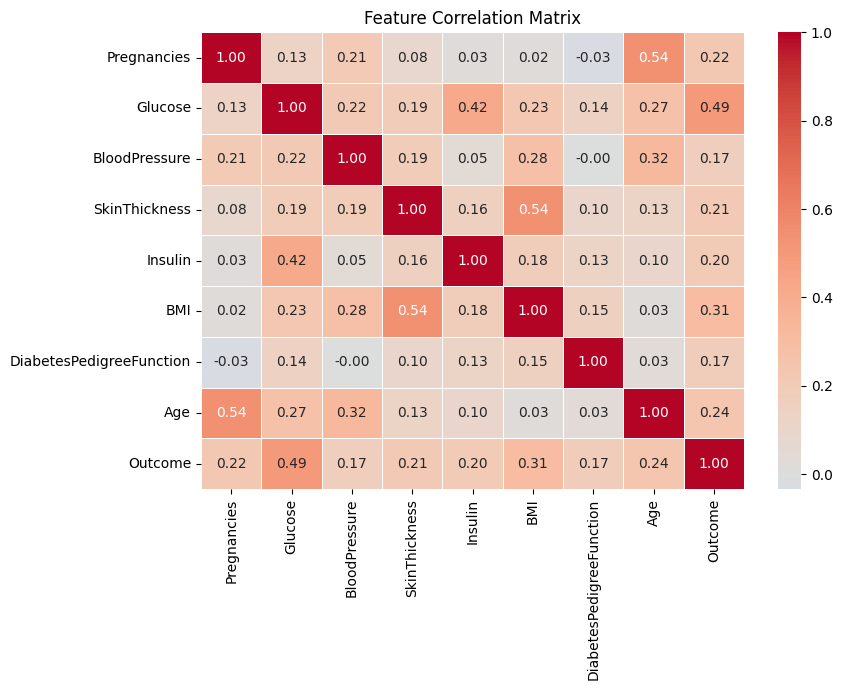

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. SHCK Feature Selection (Algorithm 1)

In [ ]:
def compute_cluster_scores(X_subset, y, K):
    n_features = X_subset.shape[1]
    K = len(np.unique(y))
    
    min_label, max_label = np.min(y), np.max(y)
    centroids = np.random.uniform(min_label, max_label, size=K)
    
    mv = np.mean(X_subset, axis=0)
    
    feature_clusters = np.zeros(n_features, dtype=int)
    for i in range(n_features):
        distances = np.abs(mv[i] - centroids)
        feature_clusters[i] = np.argmin(distances)
    
    for j in range(K):
        assigned = [mv[i] for i in range(n_features) if feature_clusters[i] == j]
        if assigned:
            centroids[j] = np.mean(assigned)
    
    score_values = np.array([
        np.abs(mv[i] - centroids[feature_clusters[i]])
        for i in range(n_features)
    ])
    return score_values


def shck_select_feature(F_indices, score_values):
    scores = score_values[F_indices]
    total = np.sum(scores)
    if total == 0:
        probs = np.ones(len(F_indices)) / len(F_indices)
    else:
        probs = scores / total
    selected_idx = np.random.choice(len(F_indices), p=probs)
    return F_indices[selected_idx]


def shck(X_train, y_train, max_iter=50):
    n_features = X_train.shape[1]
    F = list(range(n_features))
    K = len(np.unique(y_train))
    
    dt = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE, max_depth=5)
    dt.fit(X_train[:, F], y_train)
    Aac = accuracy_score(y_train, dt.predict(X_train[:, F]))
    
    S = F.copy()
    
    for _ in range(max_iter):
        if len(F) <= 3:
            break
        
        score_values = compute_cluster_scores(X_train[:, F], y_train, K)
        
        # score_values is indexed over current F, so local indices 0..len(F)-1
        local_idx = shck_select_feature(np.arange(len(F)), score_values)
        I = F[local_idx]
        
        F_new = [f for f in F if f != I]
        
        dt_new = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE, max_depth=5)
        dt_new.fit(X_train[:, F_new], y_train)
        AacI = accuracy_score(y_train, dt_new.predict(X_train[:, F_new]))
        
        if AacI >= Aac:
            Aac = AacI
            S = F_new.copy()
            F = F_new.copy()
    
    return S

 ## Rule Extraction from Decision Tree

In [ ]:
def extract_rules_from_dt(dt, X_train, y_train, feature_indices, all_feature_names):
    tree_ = dt.tree_
    local_to_global = {i: feature_indices[i] for i in range(len(feature_indices))}
    
    rules = []
    
    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            leaf_values = tree_.value[node][0]
            predicted_class = int(np.argmax(leaf_values))
            CC = leaf_values[predicted_class]
            IC = np.sum(leaf_values) - CC
            RL = max(len(conditions), 1)
            rules.append({
                'conditions': conditions.copy(),
                'predicted_class': predicted_class,
                'CC': CC,
                'IC': IC,
                'RL': RL,
                'WOR': 0.0
            })
        else:
            local_idx = tree_.feature[node]
            global_idx = local_to_global[local_idx]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node],
                    conditions + [(global_idx, '<=', threshold)])
            recurse(tree_.children_right[node],
                    conditions + [(global_idx, '>', threshold)])
    
    recurse(0, [])
    return rules


def compute_wor(CC, IC, RL):
    term1 = (CC - IC) / (CC + IC) if (CC + IC) > 0 else 0
    term2 = CC / (IC + 1)
    term3 = IC / CC if CC > 0 else 0
    term4 = CC / RL
    return term1 + term2 - term3 + term4


def rule_matches(rule, sample):
    for (global_idx, op, threshold) in rule['conditions']:
        val = sample[global_idx]
        if op == '<=' and val > threshold:
            return False
        if op == '>' and val <= threshold:
            return False
    return True

## Algorithm 2: Rule Extraction (best WOR per fold)

In [ ]:
def extract_best_rule(rules):
    """Algorithm 2: Return rule with highest WOR."""
    best_rule = None
    best_wor = -np.inf
    
    for rule in rules:
        wor = compute_wor(rule['CC'], rule['IC'], rule['RL'])
        rule['WOR'] = wor
        if wor > best_wor:
            best_wor = wor
            best_rule = rule
    
    if best_rule:
        best_rule['WOR'] = best_wor
    
    return best_rule

## Algorithm 3 & 4: Sequential Hill Climbing Rule Pruning

In [ ]:
def evaluate_ruleset(ruleset, X_val, y_val, majority_class):
    if not ruleset:
        return 0.0
    preds = predict_with_rules(ruleset, X_val, majority_class)
    return accuracy_score(y_val, preds)


def predict_with_rules(ruleset, X, majority_class=0):
    preds = []
    for sample in X:
        matched = False
        for rule in ruleset:
            if rule_matches(rule, sample):
                preds.append(rule['predicted_class'])
                matched = True
                break
        if not matched:
            preds.append(majority_class)
    return np.array(preds)


def sequential_hill_climbing_prune(initial_ruleset, X_train, y_train):
    majority_class = int(np.bincount(y_train).argmax())
    P = initial_ruleset.copy()
    Aac = evaluate_ruleset(P, X_train, y_train, majority_class)
    
    Flag = 0
    while Flag != 1:
        improved = False
        for i in range(len(P)):
            Rule_set_new = [r for j, r in enumerate(P) if j != i]
            Aac_new = evaluate_ruleset(Rule_set_new, X_train, y_train, majority_class)
            if Aac_new >= Aac:
                Aac = Aac_new
                P = Rule_set_new
                improved = True
                break
        if not improved:
            Flag = 1
    
    return P, Aac

## Full pipeline

In [ ]:
def run_diaberules(X, y, feature_names):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    
    initial_transparent_ruleset = []
    fold_selected_features = []
    
    folds = list(skf.split(X, y))
    
    print("=== Phase 1 & 2: SHCK + Rule Generation ===")
    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        selected_features = shck(X_train, y_train, max_iter=50)
        fold_selected_features.append(selected_features)
        
        dt = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE, max_depth=5)
        dt.fit(X_train[:, selected_features], y_train)
        
        rules = extract_rules_from_dt(dt, X_train, y_train, selected_features, feature_names)
        
        best_rule = extract_best_rule(rules)
        if best_rule:
            initial_transparent_ruleset.append(best_rule)
        
        print(f"Fold {fold_idx+1}: selected {len(selected_features)} features, "
              f"WOR of best rule: {best_rule['WOR']:.2f}")
    
    print(f"\nInitial Transparent Ruleset size: {len(initial_transparent_ruleset)}")
    
    print("\n=== Phase 3 & 4: Rule Pruning ===")
    final_rules, final_acc = sequential_hill_climbing_prune(
        initial_transparent_ruleset, X, y
    )
    
    print(f"Intelligible Insight Rules count: {len(final_rules)}")
    print(f"Rule set accuracy: {final_acc*100:.2f}%")
    
    return final_rules, initial_transparent_ruleset, fold_selected_features


final_rules, initial_ruleset, fold_features = run_diaberules(X, y, feature_names)

=== Phase 1 & 2: SHCK + Rule Generation ===
Fold 1: selected 4 features, WOR of best rule: 2.33
Fold 2: selected 5 features, WOR of best rule: 2.33
Fold 3: selected 7 features, WOR of best rule: 2.50
Fold 4: selected 6 features, WOR of best rule: 2.33
Fold 5: selected 5 features, WOR of best rule: 2.33
Fold 6: selected 5 features, WOR of best rule: 2.33
Fold 7: selected 5 features, WOR of best rule: 2.33
Fold 8: selected 5 features, WOR of best rule: 2.33
Fold 9: selected 6 features, WOR of best rule: 2.33
Fold 10: selected 5 features, WOR of best rule: 2.33

Initial Transparent Ruleset size: 10

=== Phase 3 & 4: Rule Pruning ===
Intelligible Insight Rules count: 1
Rule set accuracy: 65.10%


## Evaluation using 10 fold CV metrics

In [ ]:
def build_initial_ruleset(X_train, y_train, n_inner_folds=10):
    """
    Inner loop: split training data into n_inner_folds,
    extract best rule from each inner fold -> Initial Transparent Ruleset.
    This matches the paper's approach of getting 10 rules from 10 folds.
    """
    inner_skf = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=RANDOM_STATE)
    initial_ruleset = []
    
    for inner_train_idx, _ in inner_skf.split(X_train, y_train):
        X_inner = X_train[inner_train_idx]
        y_inner = y_train[inner_train_idx]
        
        sel_feats = shck(X_inner, y_inner, max_iter=50)
        
        dt = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE, max_depth=5)
        dt.fit(X_inner[:, sel_feats], y_inner)
        
        rules = extract_rules_from_dt(dt, X_inner, y_inner, sel_feats, feature_names)
        for r in rules:
            r['WOR'] = compute_wor(r['CC'], r['IC'], r['RL'])
        
        best_rule = extract_best_rule(rules)
        if best_rule:
            initial_ruleset.append(best_rule)
    
    return initial_ruleset


def evaluate_diaberules_cv(X, y, feature_names):
    outer_skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    
    accs, precs, recs, f1s = [], [], [], []
    
    for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        majority_class = int(np.bincount(y_train).argmax())
        
        # Build 10-rule initial ruleset from inner CV on training data
        initial_ruleset = build_initial_ruleset(X_train, y_train, n_inner_folds=10)
        
        # Prune using training data
        pruned_rules, train_acc = sequential_hill_climbing_prune(
            initial_ruleset, X_train, y_train
        )
        
        # Predict on held-out test fold
        preds = predict_with_rules(pruned_rules, X_test, majority_class)
        
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, zero_division=0)
        rec = recall_score(y_test, preds, zero_division=0)
        f1 = f1_score(y_test, preds, zero_division=0)
        
        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        
        print(f"Fold {fold_idx+1}: Acc={acc*100:.2f}%, "
              f"Rules={len(pruned_rules)}, TrainAcc={train_acc*100:.2f}%")
    
    print("\n=== DiabeRules 10-Fold CV Results ===")
    print(f"Accuracy  : {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}")
    print(f"Recall    : {np.mean(recs)*100:.2f}% ± {np.std(recs)*100:.2f}")
    print(f"Precision : {np.mean(precs)*100:.2f}% ± {np.std(precs)*100:.2f}")
    print(f"F1 Score  : {np.mean(f1s)*100:.2f}% ± {np.std(f1s)*100:.2f}")
    
    return accs, precs, recs, f1s

accs, precs, recs, f1s = evaluate_diaberules_cv(X, y, feature_names)

Fold 1: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 2: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 3: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 4: Acc=70.13%, Rules=1, TrainAcc=67.73%
Fold 5: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 6: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 7: Acc=62.34%, Rules=1, TrainAcc=68.16%
Fold 8: Acc=64.94%, Rules=1, TrainAcc=65.12%
Fold 9: Acc=65.79%, Rules=1, TrainAcc=65.03%
Fold 10: Acc=64.47%, Rules=1, TrainAcc=65.46%

=== DiabeRules 10-Fold CV Results ===
Accuracy  : 65.23% ± 1.84
Recall    : 1.48% ± 4.44
Precision : 10.00% ± 30.00
F1 Score  : 2.58% ± 7.74


## Display final rules

In [ ]:
def display_rules(rules, feature_names):
    print("=== Intelligible Insight Rules ===\n")
    for i, rule in enumerate(rules):
        conditions = " AND ".join(
            [f"{fname} {op} {thresh:.4f}" for fname, op, thresh in rule['conditions']]
        )
        print(f"Rule {i+1}: IF {conditions}")
        print(f"         THEN Class = {rule['predicted_class']}  (WOR={rule['WOR']:.2f})\n")

display_rules(final_rules, feature_names)

=== Intelligible Insight Rules ===

Rule 1: IF 1 <= 123.5000 AND 5 <= 26.4500 AND 4 > 48.5000
         THEN Class = 0  (WOR=2.33)

